In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("../data/raw/House_Prices.csv")
df = df.iloc[:1460].copy()

In [15]:
df = df.drop(columns="Id")
df["MSSubClass"] = df["MSSubClass"].astype("str")

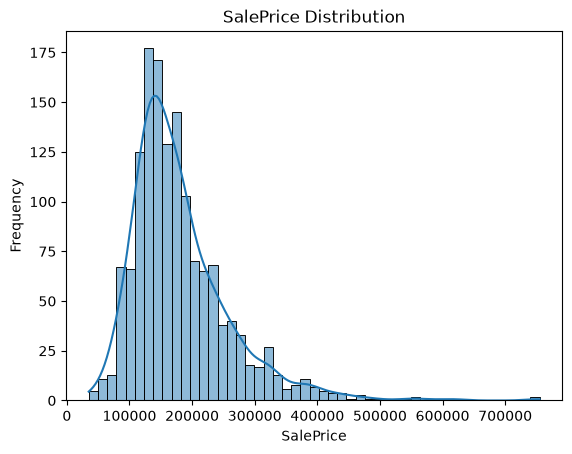

In [16]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

SalePrice is right-skewed. Most houses are concentrated around the lower-to-middle price range, while a smaller number of expensive houses create a long tail to the right

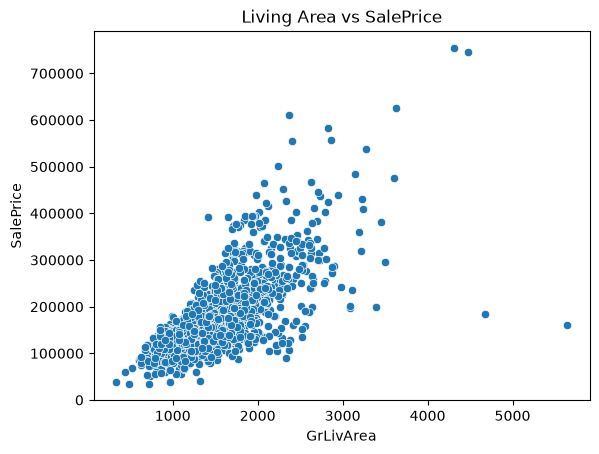

In [17]:
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")

plt.title("Living Area vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

plt.show()

GrLivArea and SalePrice show a clear positive relationship: larger living areas generally correspond to higher sale prices. A few very large houses have unusually low prices, which may be outliers.

In [18]:
df[(df["GrLivArea"] > 4000 ) & (df["SalePrice"] < 300000)][
    ["GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]
].sort_values("GrLivArea", ascending=False)

,GrLivArea,SalePrice,OverallQual,Neighborhood
1298,5642,160000.0,10,Edwards
523,4676,184750.0,10,Edwards


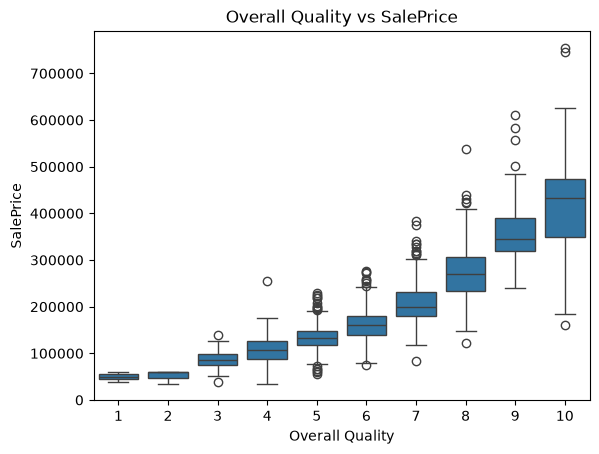

In [19]:
sns.boxplot(data=df, x="OverallQual", y="SalePrice")

plt.title("Overall Quality vs SalePrice")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")

plt.show()

OverallQual has a strong positive relationship with SalePrice. Houses with higher overall quality tend to sell for significantly higher prices. This feature is likely to be very important for the prediction model.

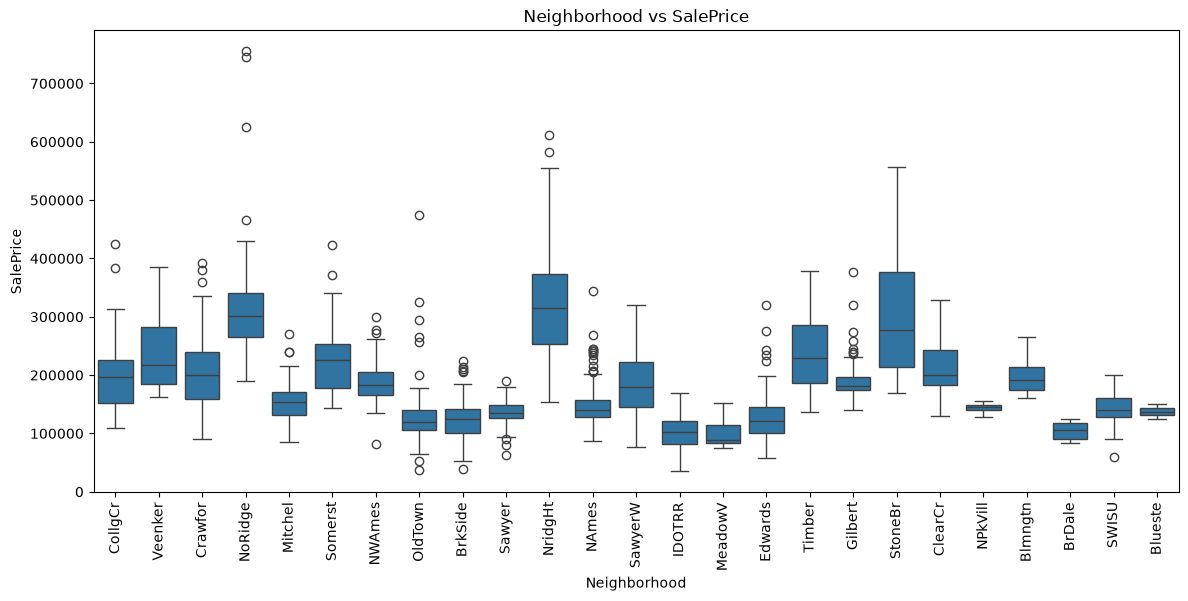

In [20]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="Neighborhood",
    y="SalePrice"
)

plt.title("Neighborhood vs SalePrice")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.xticks(rotation=90)

plt.show()

Neighborhood has a strong influence on SalePrice. Some neighborhoods have clearly higher median house prices than others, which suggests that location is an important predictive feature.

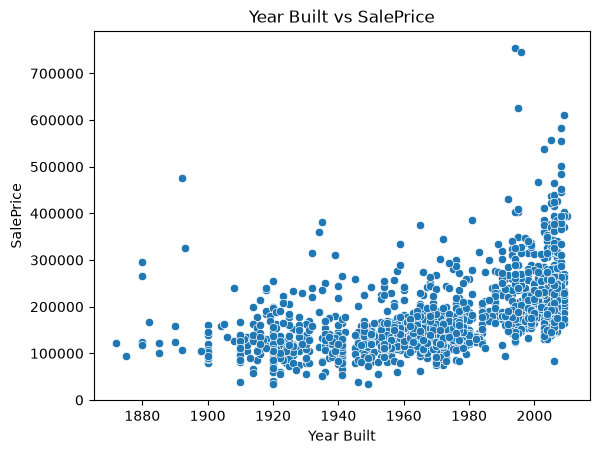

In [21]:
sns.scatterplot(data=df, x="YearBuilt", y="SalePrice")

plt.title("Year Built vs SalePrice")
plt.xlabel("Year Built")
plt.ylabel("SalePrice")

plt.show()

YearBuilt shows a positive relationship with SalePrice. Newer houses generally tend to have higher sale prices, although the relationship is not perfect and some outliers are present.

In [22]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

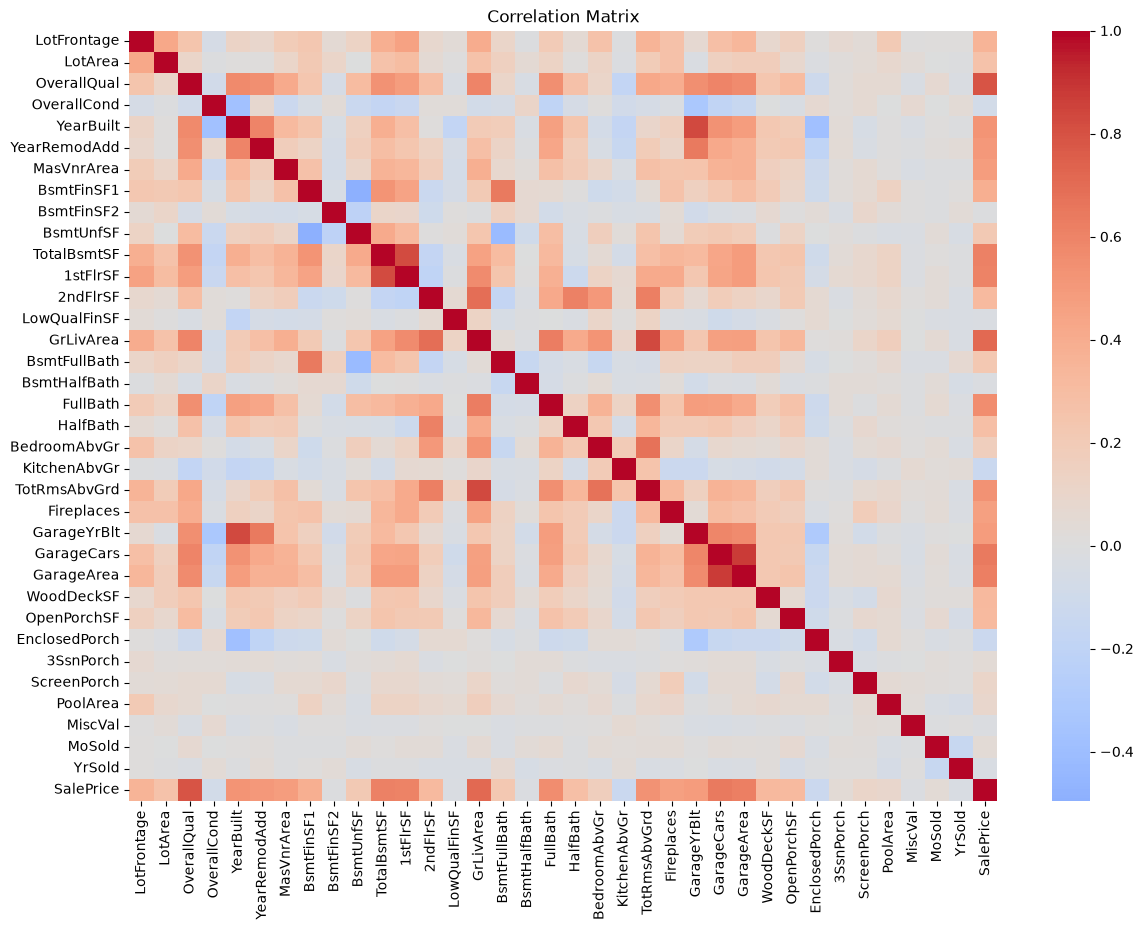

In [23]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [24]:
saleprice_corr = correlation_matrix["SalePrice"].sort_values(ascending=False)

saleprice_corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

SalePrice is most positively correlated with GrLivArea and OverallQual, followed by room count, garage capacity/area, first-floor area, basement area, and number of full bathrooms. This suggests that house size, quality, and garage-related features are important predictors of price.

SalePrice is right-skewed, with most houses concentrated in the lower-to-middle price range and a smaller number of expensive properties.
GrLivArea and OverallQual show the strongest positive relationships with SalePrice.
Neighborhood also has a clear influence on house prices, confirming that location is an important feature.
Newer houses generally tend to have higher sale prices.
The correlation analysis also highlights features such as GarageCars, GarageArea, 1stFlrSF, TotalBsmtSF, and FullBath as useful predictors.
Some extreme values and outliers are present and should be considered during modeling and evaluation.